# Statistical Analysis of GeorgiaTech injection data

TO DO:
- Make hists for injection parameters for one snapshot, and verify that these are sensible ✅
- Produce more high level plots:
- - Power production per generator type✅
- - Power mismatch by region code ✅
- - Understand Gen injection columns (`target_p`,`actual_output_total`,`online_capacity_total`)
- - Look at overloaded line/voltage limit violations region codes post powerflow ❓
- Look at how these parameter distributions change throughout one day and one year ❓

Notes:
- We have some extra injection columns which may be useful for diagnostics, and even perhaps as input to the challenge:
- - Generator and load `region_code`
- - Generator and load `disaggregation_weight`: this is binary for loads (mostly 1), but continuous for generation (decaying distribution from 0 to 1) ❓CHECK WHETHER THIS CAN BE USED TO CONNECT MAX_P TO OCT RELIABLY
- - Load `regional_consumption_mw` (verified to be simply the sum of load `p0` in the region)
- - Generator `actual_output_total`: This figure is a constant within the same `region_code` and `energy_source`, ie, can be interpreted as the generation output for a given energy source within a region. When the sum of `target_p` is calculated over each of these corresponding subsets of generators, the number consistently comes out larger by ~20%-100%. Substituting the values for `target_p` with those of `actual_output_total * disaggregation_weight` in the power flow result in better convergence (can handle ~20% more of the total power), though still don't reach 100%.
- - Generator `online_capacity_total`: (guess based on distribution resemblance to `actual_output_total`) Power output capacity in 100MW(!) by region code.❓CHECK WHETHER THIS CAN BE USED TO CONNECT MAX_P TO DISAG_W RELIABLY

- Injected data which is repeated (ie already exists in RTE dataset) seems to match (in distribution, at least).




In [96]:
import sys
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [97]:
import pypowsybl as pp
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

grid = pp.network.load(file='data/recollement-auto-20210101-0000-enrichi.xiidm.bz2')
print('Grid model loaded')


Grid model loaded


In [ ]:
df_inj_gen = pd.read_parquet("data/snapshot_gen_2021-01-01T00-00-00.parquet", engine="pyarrow")
df_inj_load = pd.read_parquet("data/snapshot_load_2021-01-01T00-00-00.parquet", engine="pyarrow")
df_inj_bus = pd.read_parquet("data/snapshot_bus_2021-01-01T00-00-00.parquet", engine="pyarrow")

df_inj_gen_mw = df_inj_gen.copy()
df_inj_gen_mw['target_p'] = df_inj_gen['target_p'] *100 #Units correction. Don´t use these units for powerflow!
df_inj_gen_mw['max_p'] = df_inj_gen['max_p'] * 100 #Units correction. Don´t use these units for powerflow!

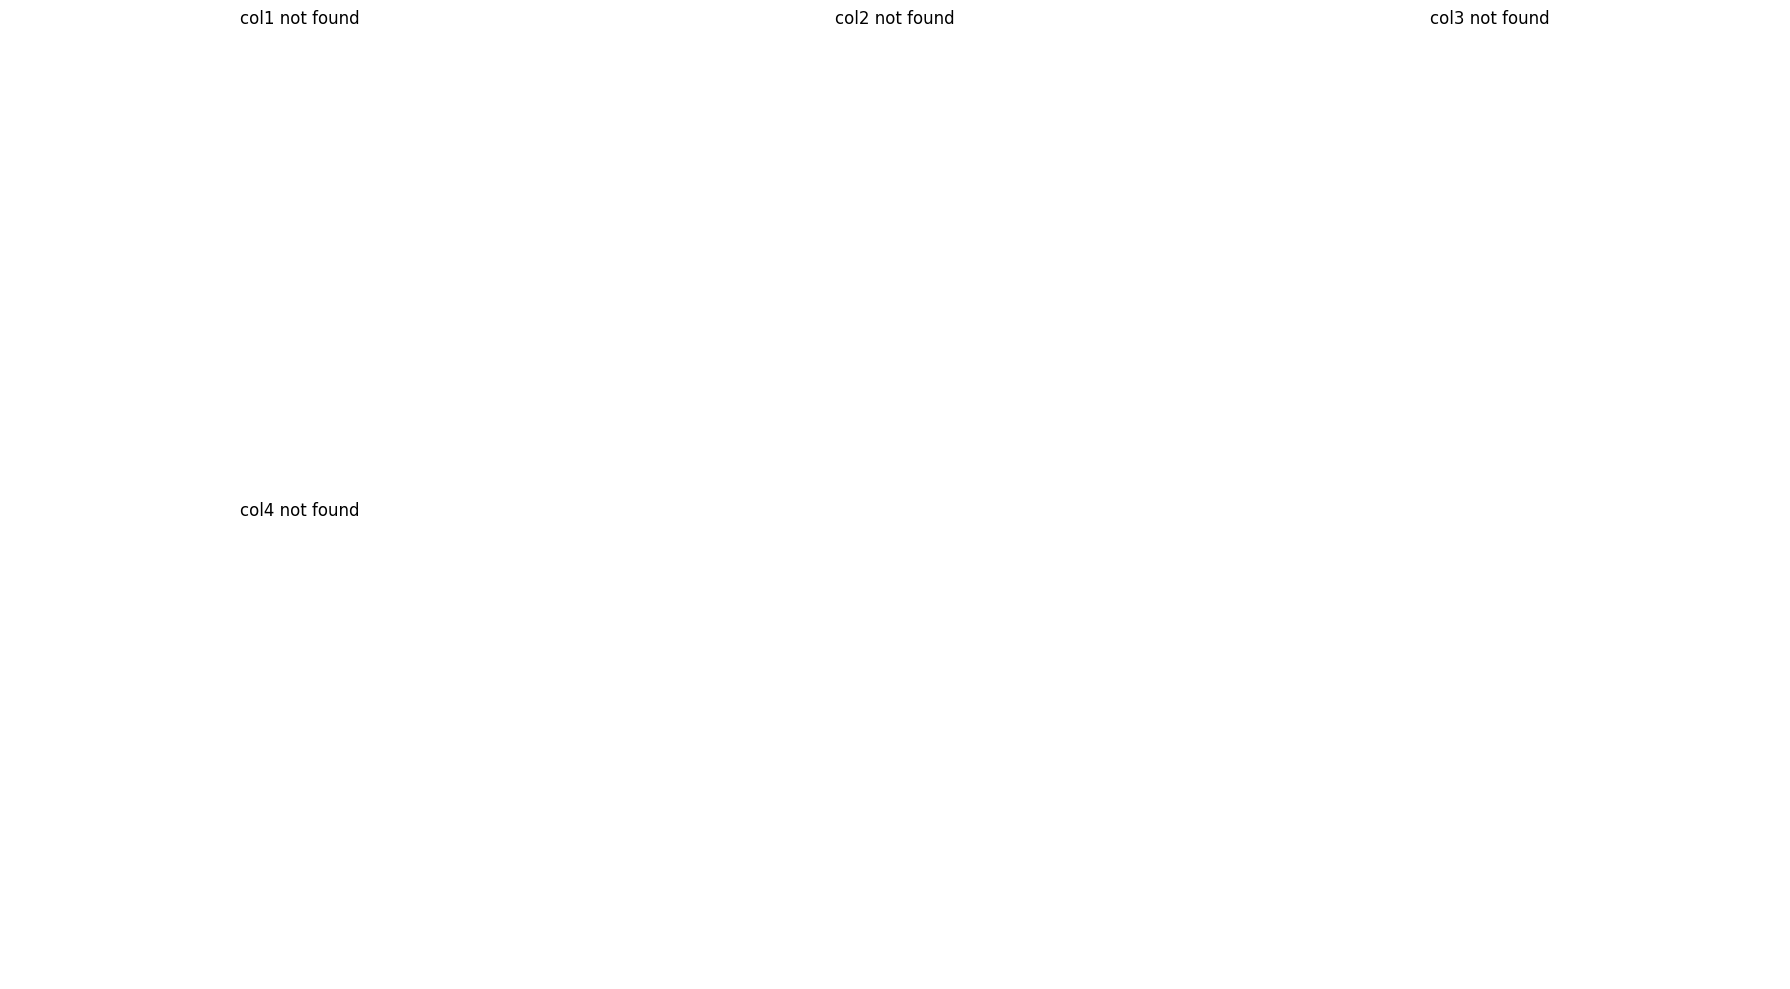

In [99]:
import math

def generate_column_plots(df, columns, dataset_name="data"):
    # Calculate grid dimensions (3 columns wide)
    n_cols = 3
    n_rows = math.ceil(len(columns) / n_cols)
    
    # Create one large figure for all plots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten()  # Flatten to iterate easily

    for i, col in enumerate(columns):
        ax = axes[i]
        
        if col not in df.columns:
            ax.set_title(f"{col} not found")
            ax.axis('off')
            continue
            
        first_val = df[col].dropna().iloc[0] if not df[col].dropna().empty else None
        
        # 1. Logic for Categorical / Strings / Booleans
        if (pd.api.types.is_bool_dtype(df[col]) or 
            pd.api.types.is_categorical_dtype(df[col]) or 
            isinstance(first_val, str)):
            
            counts = df[col].value_counts()
            counts.plot(kind='bar', color='salmon', edgecolor='black', ax=ax)
            ax.set_ylabel('Count')

        # 2. Logic for Numeric
        elif pd.api.types.is_numeric_dtype(df[col]):
            ax.hist(df[col].dropna(), bins=50, color='skyblue', edgecolor='black')
            ax.set_ylabel('Frequency')
        
        else:
            ax.set_title(f"Unsupported type: {df[col].dtype}")
            ax.axis('off')
            continue

        ax.set_title(f'Distribution of {col}')
        ax.set_xlabel(col)
        # Rotate labels for categorical plots specifically
        if isinstance(first_val, (str, bool)):
            ax.tick_params(axis='x', rotation=45)

    # Remove unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(f"{dataset_name}_summary.pdf")
    plt.show() # Renders directly in Jupyter

# Usage
my_cols = ['col1', 'col2', 'col3', 'col4'] # Example with many columns
generate_column_plots(df, my_cols, "Inj_load")

In [100]:
def generate_column_plots(df, columns, dataset_name="data"):
    for col in columns:
        if col not in df.columns:
            print(f"Skipping {col}: Column not found.")
            continue
            
        plt.figure(figsize=(10, 6))
        
        # Get the first non-null value to check its actual Python type
        first_val = df[col].dropna().iloc[0] if not df[col].dropna().empty else None
        
        # 1. Logic for Categorical / Strings / Booleans
        if (pd.api.types.is_bool_dtype(df[col]) or 
            pd.api.types.is_categorical_dtype(df[col]) or 
            isinstance(first_val, str)): # <--- The "Catch-All" for 'str' type
            
            counts = df[col].value_counts()
            counts.plot(kind='bar', color='salmon', edgecolor='black')
            plt.ylabel('Count')
            plt.title(f'Distribution of {col}')
            plt.xticks(rotation=45, ha='right')

        # 2. Logic for Numeric
        elif pd.api.types.is_numeric_dtype(df[col]):
            plt.hist(df[col].dropna(), bins=100, color='skyblue', edgecolor='black')
            plt.ylabel('Frequency')
            plt.title(f'Histogram of {col}')
        
        else:
            print(f"Skipping {col}: Unsupported data type {df[col].dtype}")
            plt.close()
            continue

        plt.xlabel(col)
        plt.tight_layout()
        
        filename = f"{dataset_name}_{col}.pdf"
        plt.savefig(filename)
        plt.close()
        print(f"Saved: {filename}")


# --- Example Usage ---
df = df_inj_gen_mw

# df_filtered = df.loc[df['element_type'] == 'TWO_WINDINGS_TRANSFORMER'] 
# df_filtered = df_filtered.loc[df_filtered['name'] == 'permanent_limit'] 

my_cols = ['actual_output_total']
generate_column_plots(df, my_cols, "Inj_load")

Saved: Inj_load_actual_output_total.pdf


C:\Users\Josh (eRoots)\AppData\Local\Temp\ipykernel_18440\1746413916.py:14: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  pd.api.types.is_categorical_dtype(df[col]) or


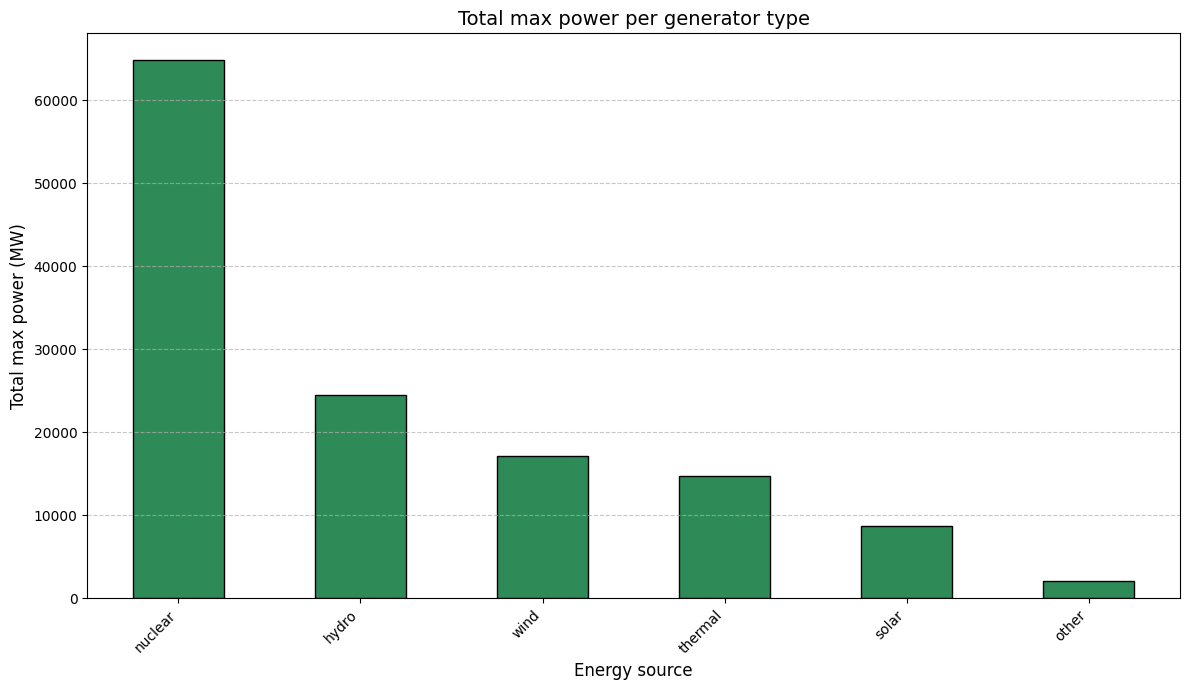

Plot saved as: Inj_gen_max_power_by_type.pdf


In [101]:
def plot_power_by_type(df, dataset_name):
    # 1. Clean the data: Ensure target_p is numeric (in case of 'str' issues)
    df['max_p'] = pd.to_numeric(df['max_p'], errors='coerce').fillna(0)

    # 2. Group by 'energy_source' and sum the 'target_p' column
    # This replaces the "running sum" logic with a single vectorized command
    power_sums = df.groupby('energy_source')['max_p'].sum().sort_values(ascending=False)

    # 3. Create the Bar Chart
    plt.figure(figsize=(12, 7))
    power_sums.plot(kind='bar', color='seagreen', edgecolor='black')

    # Formatting the plot
    plt.title(f'Total max power per generator type', fontsize=14)
    plt.xlabel('Energy source', fontsize=12)
    plt.ylabel('Total max power (MW)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()

    # 4. Save the result
    filename = f"{dataset_name}_power_by_type.pdf"
    plt.savefig(filename)
    plt.show() # Shows it in your VS Code cell
    print(f"Plot saved as: {filename}")

# Example Usage:

df = df_inj_gen_mw
plot_power_by_type(df, "Inj_gen_max")

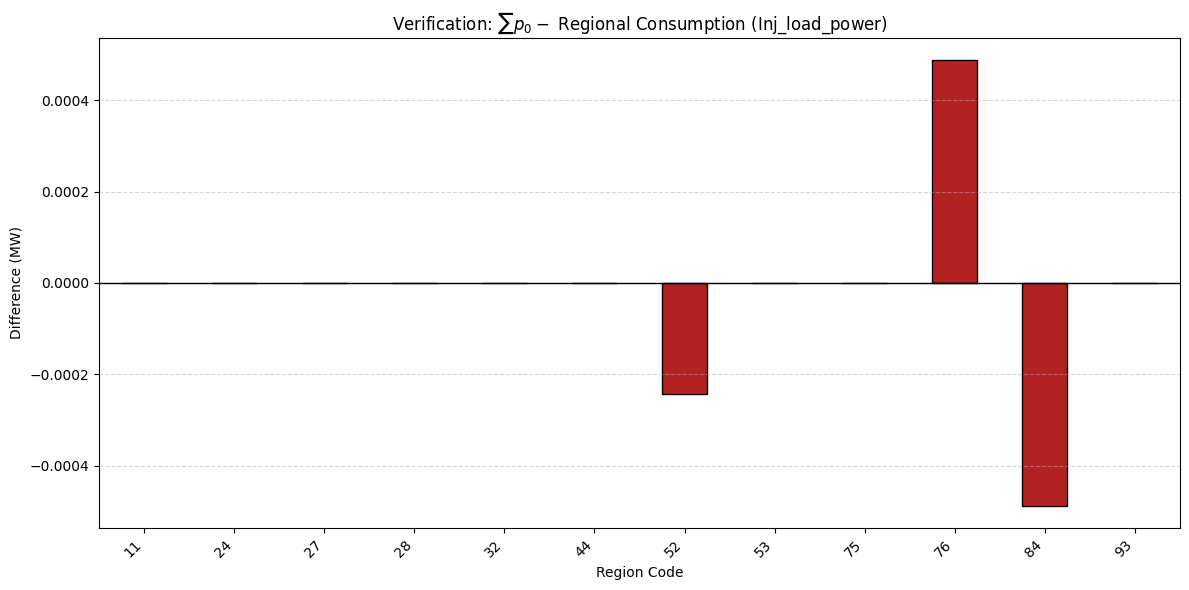

Verification Complete: All regions match.


In [102]:
def verify_regional_consumption(df, dataset_name):
    # 1. Ensure numeric types for calculation
    df['p0'] = pd.to_numeric(df['p0'], errors='coerce').fillna(0)
    df['regional_consumption_mw'] = pd.to_numeric(df['regional_consumption_mw'], errors='coerce').fillna(0)

    # 2. Group by region_code
    # We sum p0, and take the 'first' regional_consumption_mw since it's the same for all rows in a group
    verification = df.groupby('region_code').agg({
        'p0': 'sum',
        'regional_consumption_mw': 'first'
    })

    # 3. Calculate the difference (Residual)
    # Calculation: Sum(p0) - regional_consumption
    verification['diff'] = verification['p0'] - verification['regional_consumption_mw']

    # 4. Plotting the Differences
    plt.figure(figsize=(12, 6))
    
    # Using a bar chart to identify specific regions
    verification['diff'].plot(kind='bar', 
                             color=['firebrick' if abs(x) > 1e-5 else 'skyblue' for x in verification['diff']],
                             edgecolor='black')

    plt.axhline(0, color='black', linewidth=1) # Add a baseline at zero
    plt.title(f'Verification: $\sum p_0 -$ Regional Consumption ({dataset_name})')
    plt.xlabel('Region Code')
    plt.ylabel('Difference (MW)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    
    # 5. Save and Show
    filename = f"{dataset_name}_regional_verification.pdf"
    plt.savefig(filename)
    plt.show()

    # Output regions with significant mismatches to the console
    mismatches = verification[verification['diff'].abs() > 0.01]
    if not mismatches.empty:
        print("--- Significant Mismatches Found ---")
        print(mismatches['diff'])
    else:
        print("Verification Complete: All regions match.")

# Example Usage:
df= df_inj_load
verify_regional_consumption(df, "Inj_load_power")

In [103]:
df_inj_gen_mw.to_csv('Injected_generation_mw.csv',index = False)

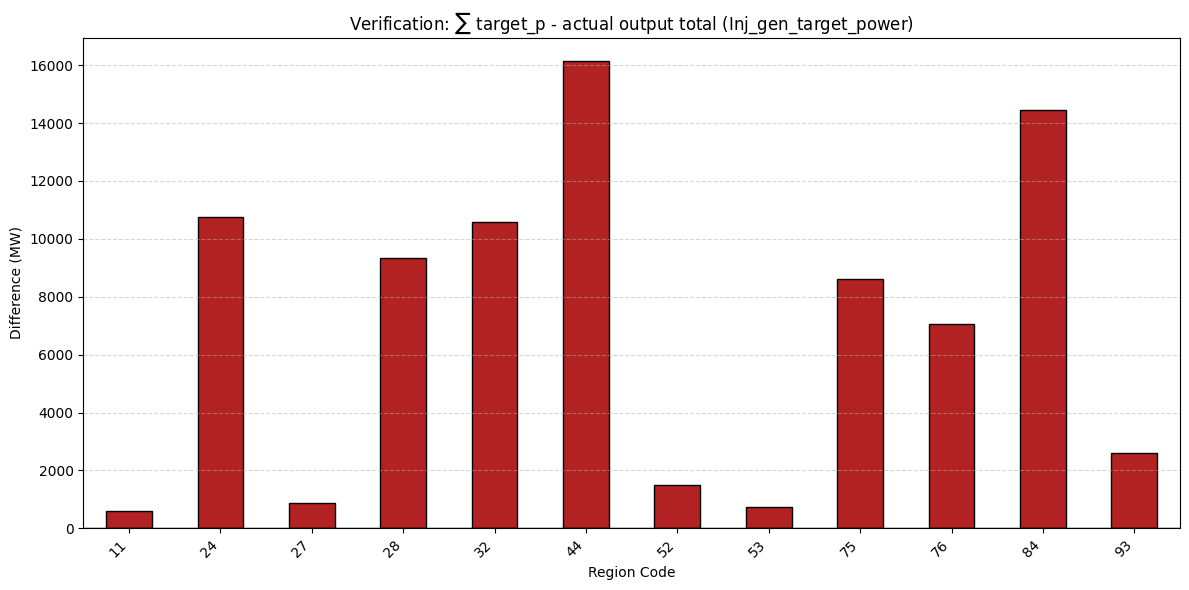

--- Significant Mismatches Found ---
region_code
11      589.700012
24    10763.474609
27      870.540039
28     9330.169922
32    10573.150391
44    16147.339844
52     1491.700073
53      722.619995
75     8623.190430
76     7043.609863
84    14466.490234
93     2604.000000
Name: diff, dtype: float32


In [104]:
def verify_regional_consumption(df, dataset_name):
    # 1. Ensure numeric types for calculation
    df['target_p'] = pd.to_numeric(df['target_p'], errors='coerce').fillna(0)
    df['actual_output_total'] = pd.to_numeric(df['actual_output_total'], errors='coerce').fillna(0)

    # 2. Group by region_code
    # We sum p0, and take the 'first' actual_output_total since it's the same for all rows in a group
    verification = df.groupby('region_code').agg({
        'target_p': 'sum',
        'actual_output_total': 'first'
    })

    # 3. Calculate the difference (Residual)
    # Calculation: Sum(p0) - regional_consumption
    verification['diff'] = verification['target_p'] - verification['actual_output_total']

    # 4. Plotting the Differences
    plt.figure(figsize=(12, 6))
    
    # Using a bar chart to identify specific regions
    verification['diff'].plot(kind='bar', 
                             color=['firebrick' if abs(x) > 1e-5 else 'skyblue' for x in verification['diff']],
                             edgecolor='black')

    plt.axhline(0, color='black', linewidth=1) # Add a baseline at zero
    plt.title(f'Verification: $\sum$ target_p - actual output total ({dataset_name})')
    plt.xlabel('Region Code')
    plt.ylabel('Difference (MW)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    
    # 5. Save and Show
    filename = f"{dataset_name}_regional_verification.pdf"
    plt.savefig(filename)
    plt.show()

    # Output regions with significant mismatches to the console
    mismatches = verification[verification['diff'].abs() > 0.01]
    if not mismatches.empty:
        print("--- Significant Mismatches Found ---")
        print(mismatches['diff'])
    else:
        print("Verification Complete: All regions match.")

# Example Usage:
df= df_inj_gen_mw
verify_regional_consumption(df, "Inj_gen_target_power")

In [105]:
# Check the multiplier
comparison = df_inj_gen_mw.groupby('region_code').agg({'target_p': 'sum', 'actual_output_total': 'first'})
comparison['ratio'] = comparison['target_p'] / comparison['actual_output_total']
print(comparison['ratio'])

region_code
11           inf
24    513.546387
27     21.727144
28    519.342773
32     29.422447
44           inf
52           inf
53           inf
75           inf
76           inf
84      6.424256
93           inf
Name: ratio, dtype: float32


In [106]:
def debug_generation_mismatch(df):
    # 1. Clean data types
    cols = ['target_p', 'max_p', 'disaggregation_weight', 'online_capacity_total', 'actual_output_total']
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
    
    # 2. Regional Aggregation
    debug = df.groupby('region_code').agg({
        'target_p': ['sum', 'count'],
        'max_p': 'sum',
        'disaggregation_weight': 'sum',
        'online_capacity_total': 'first',
        'actual_output_total': 'first'
    })
    
    # Flatten multi-index columns
    debug.columns = ['sum_target_p', 'unit_count', 'sum_max_p', 'sum_weights', 'oct_first', 'aot_first']

    # 3. Test the 3 Potential Truths
    # Relation A: Does Sum(target_p) == AOT?
    debug['A_AOT_Diff'] = debug['sum_target_p'] - debug['aot_first']
    
    # Relation B: Does Sum(max_p) == OCT * 100?
    debug['B_OCT_Match'] = debug['sum_max_p'] - (debug['oct_first'] * 100)
    
    # Relation C: Do weights add up to 1.0 (or 100)?
    debug['C_Weight_Total'] = debug['sum_weights']

    # 4. Filter for only problematic regions
    problems = debug[(debug['A_AOT_Diff'].abs() > 0.1) | (debug['B_OCT_Match'].abs() > 0.1)]
    
    print("--- REGIONAL DEBUG REPORT ---")
    if problems.empty:
        print("No mathematical inconsistencies found.")
    else:
        print(problems[['unit_count', 'sum_target_p', 'aot_first','A_AOT_Diff', 'B_OCT_Match', 'C_Weight_Total']])
        
    return debug

# Run it
debug_results = debug_generation_mismatch(df_inj_gen_mw)

--- REGIONAL DEBUG REPORT ---
             unit_count  sum_target_p  aot_first    A_AOT_Diff   B_OCT_Match  \
region_code                                                                    
11                  198    589.700012        0.0    589.700012   2378.300049   
24                  290  10784.474609       21.0  10763.474609  13247.784180   
27                  329    912.540039       42.0    870.540039    859.640015   
28                  288   9348.169922       18.0   9330.169922  13531.669922   
32                  478  10945.150391      372.0  10573.150391   7774.690430   
44                  689  16147.339844        0.0  16147.339844  21899.878906   
52                  355   1491.700073        0.0   1491.700073   4074.589844   
53                  319    722.619995        0.0    722.619995   1789.830078   
75                  833   8623.190430        0.0   8623.190430  10585.587891   
76                  825   7043.609863        0.0   7043.609863  11497.200195   
84        

In [107]:
import pandas as pd

def verify_by_fuel_type(df):
    # Ensure numeric types
    for c in ['target_p', 'actual_output_total', 'disaggregation_weight']:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

    # Group by Region AND Energy Source
    # We use a single snapshot to prevent time-stacking
    latest_time = df['datetime'].max()
    sub = df[df['datetime'] == latest_time].copy()

    fuel_check = sub[sub['connected'] == True].groupby(['region_code', 'energy_source']).agg({
        'disaggregation_weight': 'sum',
        'target_p': 'sum',
        'actual_output_total': 'first'
    })

    fuel_check['diff'] = fuel_check['target_p'] - fuel_check['actual_output_total']
    
    # Identify which fuel type actually "owns" the AOT column
    # We look for the one where the weight sum is closest to 1.0
    print("--- FUEL-TYPE SPECIFIC VERIFICATION ---")
    print(fuel_check)
    
    return fuel_check

# Run this to see which energy_source matches the regional total
fuel_analysis = verify_by_fuel_type(df_inj_gen_mw)

--- FUEL-TYPE SPECIFIC VERIFICATION ---
                           disaggregation_weight      target_p  \
region_code energy_source                                        
11          hydro                            1.0    240.000000   
            solar                            1.0      0.000000   
            thermal                          1.0    249.699997   
            wind                             1.0    100.000000   
24          hydro                            1.0     72.539993   
            nuclear                          1.0   9415.000000   
            solar                            1.0      0.000000   
            thermal                          1.0     33.200001   
            wind                             1.0   1263.734985   
27          hydro                            1.0     91.040001   
            other                            1.0      0.000000   
            solar                            1.0      0.000000   
            thermal                 

In [108]:
import pandas as pd

def audit_aot_and_weights(df):
    # Ensure columns are numeric for accurate calculation and grouping
    df['actual_output_total'] = pd.to_numeric(df['actual_output_total'], errors='coerce')
    df['disaggregation_weight'] = pd.to_numeric(df['disaggregation_weight'], errors='coerce')
    
    # 1. Isolate the latest snapshot
    latest_ts = df['datetime'].max()
    df_snapshot = df[df['datetime'] == latest_ts].copy()
    
    # 2. Group by the unique identifiers requested
    # We aggregate to get both the frequency (count) and the average weight
    audit = df_snapshot.groupby(['region_code', 'energy_source', 'actual_output_total']).agg(
        occurrence_count=('actual_output_total', 'count'),
        avg_disaggregation_weight=('disaggregation_weight', 'mean')
    ).reset_index()
    
    # 3. Sort by region and source for clear visual inspection
    audit = audit.sort_values(['region_code', 'energy_source', 'actual_output_total'])
    
    # 4. Print the final audit table
    print(f"--- DETAILED INJECTION & WEIGHT AUDIT (Snapshot: {latest_ts}) ---")
    print(audit.to_string(index=False))
    
    return audit

# Run the script against your dataframe
audit_results = audit_aot_and_weights(df_inj_gen)

--- DETAILED INJECTION & WEIGHT AUDIT (Snapshot: 2021-01-01 00:00:00) ---
 region_code energy_source  actual_output_total  occurrence_count  avg_disaggregation_weight
          11         hydro                  3.0                 3                   0.333333
          11         solar                  0.0               173                   0.005780
          11       thermal                418.0                16                   0.062500
          11          wind                  1.0                 6                   0.166667
          24         hydro                 21.0                 2                   0.500000
          24       nuclear               9075.0                12                   0.083333
          24         solar                  0.0               222                   0.004505
          24       thermal                105.0                 6                   0.166667
          24          wind                 15.0                48                   0.020

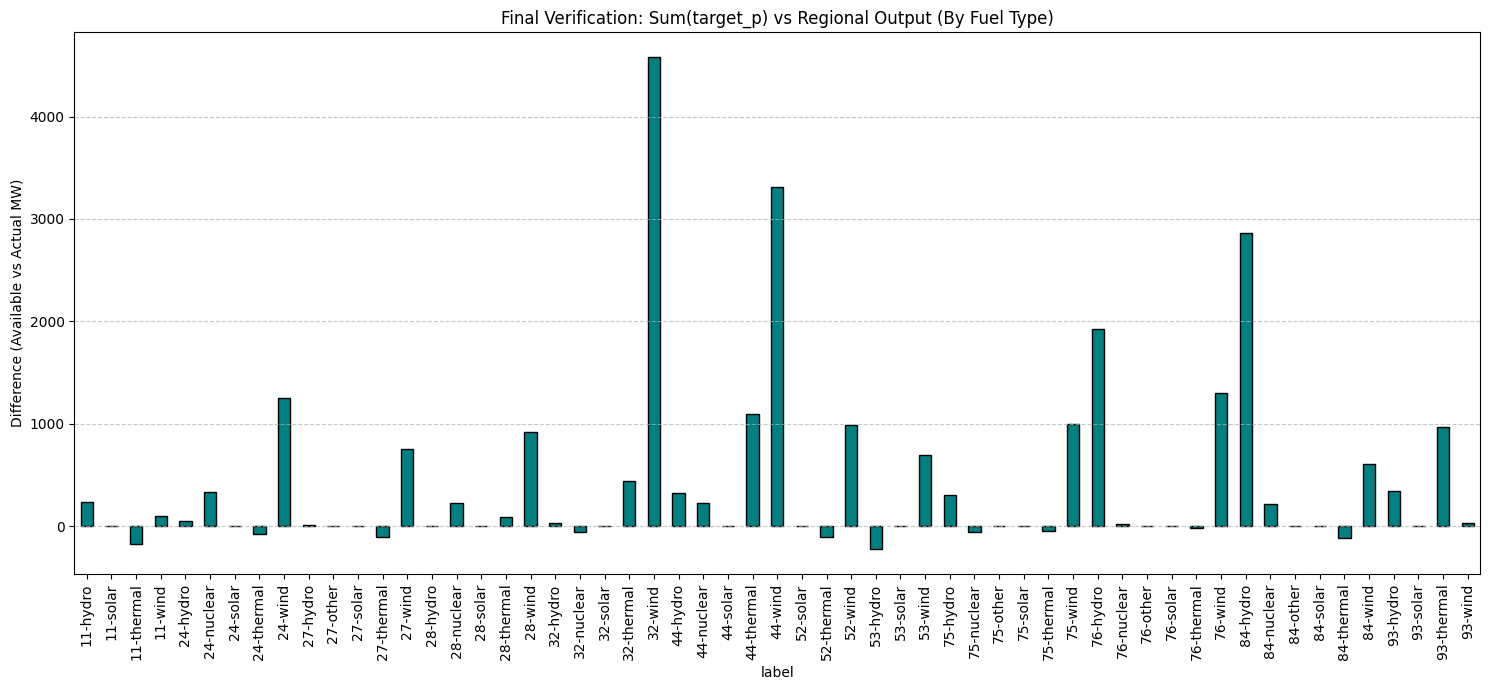

In [109]:
import pandas as pd
import matplotlib.pyplot as plt

def final_correct_verification(df):
    # 1. Standardize numeric columns
    cols = ['target_p', 'actual_output_total', 'disaggregation_weight']
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

    # 2. Filter for a single snapshot and connected units
    latest = df['datetime'].max()
    sub = df[(df['datetime'] == latest) & (df['connected'] == True)].copy()

    # 3. Aggregate by Region AND Fuel Type
    # This is the key to getting disaggregation_weight sum = 1.0
    verified = sub.groupby(['region_code', 'energy_source']).agg({
        'target_p': 'sum',
        'actual_output_total': 'first',
        'disaggregation_weight': 'sum'
    }).reset_index()

    # 4. Calculate Difference
    verified['diff'] = verified['target_p'] - verified['actual_output_total']
    
    # Create a unique label for the plot: "Region-Fuel"
    verified['label'] = verified['region_code'].astype(str) + "-" + verified['energy_source']

    # 5. Plotting
    plt.figure(figsize=(15, 7))
    verified.set_index('label')['diff'].plot(kind='bar', color='teal', edgecolor='black')
    plt.title('Final Verification: Sum(target_p) vs Regional Output (By Fuel Type)')
    plt.ylabel('Difference (Available vs Actual MW)')
    plt.xticks(rotation=90)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    return verified

# Run the final logic
final_stats = final_correct_verification(df_inj_gen_mw)

In [110]:
import pandas as pd

def diagnose_p_sandwich(df):
    # Calculate derived dispatch
    df['derived_dispatch'] = df['actual_output_total'] * df['disaggregation_weight']
    
    # Check 1: Is Target >= Dispatch? (Must be true for feasibility)
    target_gt_dispatch = (df['target_p'] >= df['derived_dispatch'] - 0.1).mean() * 100
    
    # Check 2: Is Max >= Target? (Must be true for physical reality)
    max_gt_target = (df['max_p'] >= df['target_p'] - 0.1).mean() * 100
    
    # Check 3: Correlation
    correlation = df['target_p'].corr(df['max_p'])

    print(f"--- Operational Logic Audit ---")
    print(f"Target >= Dispatch in {target_gt_dispatch:.1f}% of rows")
    print(f"Max >= Target in {max_gt_target:.1f}% of rows")
    print(f"Correlation (Target vs Max): {correlation:.4f}")
    
    return df[['max_p', 'target_p', 'derived_dispatch']].head(10)

# Run the final diagnostic
print(diagnose_p_sandwich(df_inj_gen_mw))

--- Operational Logic Audit ---
Target >= Dispatch in 99.3% of rows
Max >= Target in 100.0% of rows
Correlation (Target vs Max): 0.8532
       max_p   target_p  derived_dispatch
0  15.000001  15.000001          7.232177
1  15.000001  15.000001          7.232177
2   0.700000   0.000000          0.000000
3   0.000000   0.000000          0.000000
4  14.400000  14.400000          1.081424
5   0.300000   0.000000          0.000000
6   0.300000   0.000000          0.000000
7  42.599998  42.599998          3.199212
8   2.100000   0.000000          0.000000
9  35.279999  35.279999         10.213400


In [111]:
# This checks if every generator in a region agrees on how big the total region is
df= df_inj_gen_mw.copy()
df['implied_regional_capacity'] = df['max_p'] / df['disaggregation_weight']
print(df.groupby(['region_code', 'energy_source'])['implied_regional_capacity'].std())

region_code  energy_source
11           hydro            0.000000
             solar                 NaN
             thermal               NaN
             wind             0.000000
24           hydro            0.000005
             nuclear               NaN
             solar                 NaN
             thermal               NaN
             wind                  NaN
27           hydro                 NaN
             other                 NaN
             solar                 NaN
             thermal               NaN
             wind             0.000026
28           hydro                 NaN
             nuclear               NaN
             solar                 NaN
             thermal               NaN
             wind             0.000031
32           hydro            0.000001
             nuclear               NaN
             solar                 NaN
             thermal               NaN
             wind                  NaN
44           hydro                 Na

In [112]:
import pandas as pd

def verify_disaggregation_integrity(df):
    # 1. Calculate the 'Implied Total' for every row
    # If the logic is sound, this should be identical for all units in a group
    df['implied_regional_cap'] = df['max_p'] / df['disaggregation_weight']
    
    # 2. Calculate the unit's 'Fair Share' of the actual output
    df['calculated_unit_output'] = df['actual_output_total'] * df['disaggregation_weight']
    
    # 3. Validation: Does the sum of weights explain the AOT?
    # Note: We expect weight_sum to be < 1.0 if the list is incomplete
    validation = df.groupby(['region_code', 'energy_source']).agg({
        'disaggregation_weight': 'sum',
        'actual_output_total': 'first',
        'target_p': 'sum'
    })
    
    # This is the % of the regional output represented by the units in your list
    validation['coverage_ratio'] = validation['disaggregation_weight'] 
    
    print("--- DATA COVERAGE REPORT ---")
    print(validation[['coverage_ratio', 'actual_output_total']])
    return validation

# Run the final valid verification
coverage_report = verify_disaggregation_integrity(df_inj_gen_mw)

--- DATA COVERAGE REPORT ---
                           coverage_ratio  actual_output_total
region_code energy_source                                     
11          hydro                     1.0                  3.0
            solar                     1.0                  0.0
            thermal                   1.0                418.0
            wind                      1.0                  1.0
24          hydro                     1.0                 21.0
            nuclear                   1.0               9075.0
            solar                     1.0                  0.0
            thermal                   1.0                105.0
            wind                      1.0                 15.0
27          hydro                     1.0                 81.0
            other                     1.0                  0.0
            solar                     1.0                  0.0
            thermal                   1.0                127.0
            wind          

In [113]:
# Group by region and fuel to find gaps in the asset list
audit = df.groupby(['region_code', 'energy_source']).agg({
    'disaggregation_weight': 'sum',
    'actual_output_total': 'first'
})

# Identify 'Ghost Generation': Output exists, but no units are mapped
ghosts = audit[(audit['actual_output_total'] > 0) & (audit['disaggregation_weight'] == 0)]

print("--- GHOST GENERATION DETECTED ---")
print("Regions where output is reported but units are missing from the table:")
print(ghosts)


--- GHOST GENERATION DETECTED ---
Regions where output is reported but units are missing from the table:
                           disaggregation_weight  actual_output_total
region_code energy_source                                            
53          thermal                          0.0                234.0


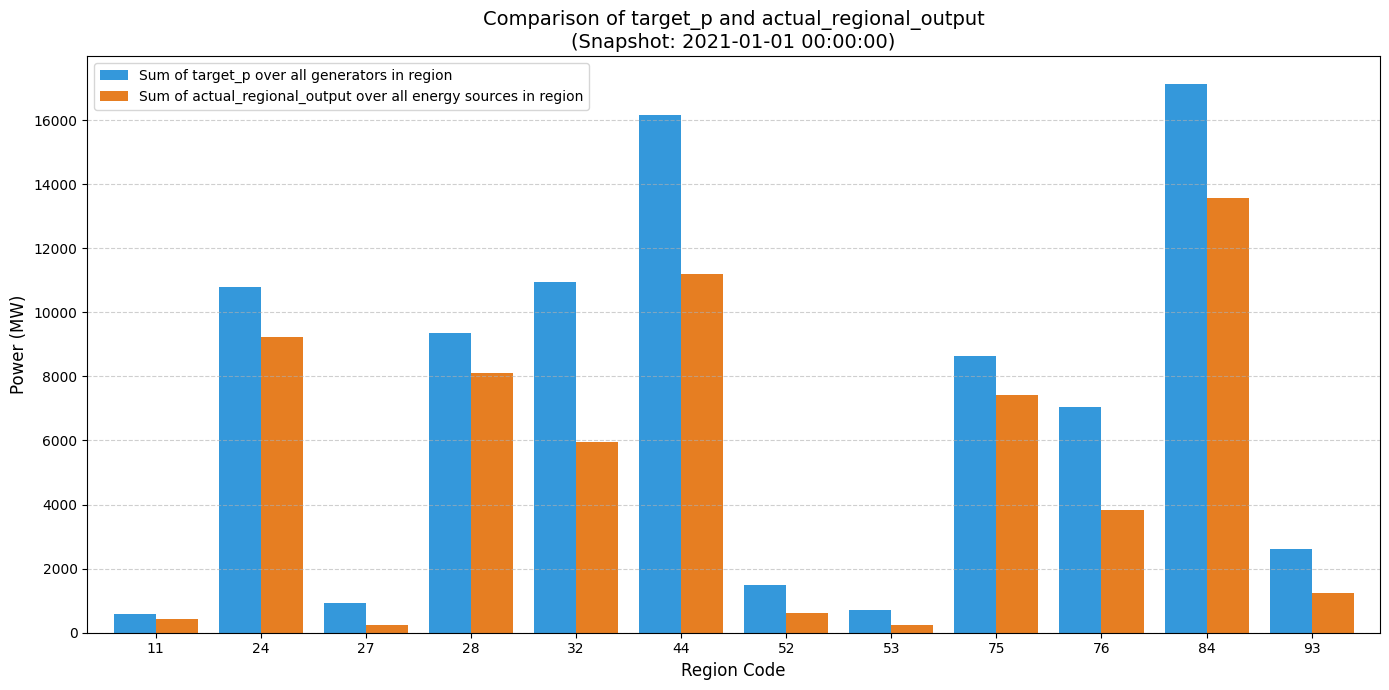

In [114]:
import pandas as pd
import matplotlib.pyplot as plt

def generate_comparison_plot(df):
    # 1. Standardize numeric columns
    cols = ['target_p', 'actual_output_total', 'connected']
    for col in cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    # 2. Filter for latest snapshot and connected units only
    latest_ts = df['datetime'].max()
    df_clean = df[(df['datetime'] == latest_ts) & (df['connected'] == True)].copy()

    # 3. Handle the Ghost Region (Region 53 Thermal)
    # We remove this specific fuel group because the coverage_ratio is 0.0
    df_clean = df_clean[~((df_clean['region_code'] == 53) & (df_clean['energy_source'] == 'thermal'))]

    # 4. Aggregation
    # We sum target_p (the forecasted availability of all units)
    # We take 'first' for actual_output_total because it's already a regional total per fuel
    fuel_summary = df_clean.groupby(['region_code', 'energy_source']).agg({
        'target_p': 'sum',
        'actual_output_total': 'first'
    }).reset_index()

    # 5. Final Regional Totals
    regional_summary = fuel_summary.groupby('region_code').agg({
        'target_p': 'sum',
        'actual_output_total': 'sum'
    })

    # 6. Plotting
    ax = regional_summary.plot(kind='bar', figsize=(14, 7), width=0.8, color=['#3498db', '#e67e22'])
    
    plt.title(f'Comparison of target_p and actual_regional_output\n(Snapshot: {latest_ts})', fontsize=14)
    plt.ylabel('Power (MW)', fontsize=12)
    plt.xlabel('Region Code', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(['Sum of target_p over all generators in region', 'Sum of actual_regional_output over all energy sources in region'], loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# Run the generator
generate_comparison_plot(df_inj_gen_mw)

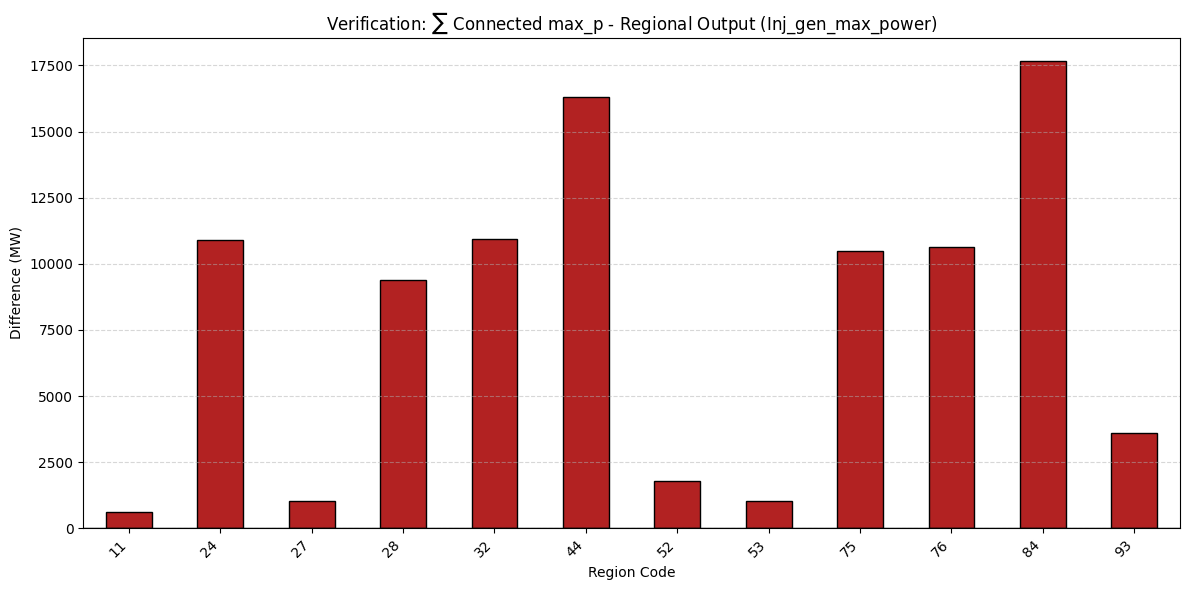

--- Mismatches Found in 12 Regions ---
             sum_max_p_connected  online_capacity_total          diff
region_code                                                          
11                    626.500000               0.280000    626.219971
24                  10898.074219               0.725400  10897.348633
27                   1041.739990               7.975000   1033.765015
28                   9399.169922               9.410500   9389.759766
32                  10986.950195              49.534698  10937.415039
44                  16320.729492               1.733900  16318.995117
52                   1803.780029               2.972900   1800.807129
53                   1043.989990               0.148600   1043.841431
75                  10498.868164              18.229900  10480.638672
76                  10633.330078              15.677200  10617.653320
84                  17723.699219              55.315300  17668.384766
93                   3614.530029              10.10

In [115]:
def verify_connected_regional_power(df, dataset_name="Injection_Check"):
    # 1. Data Cleaning
    df['max_p'] = pd.to_numeric(df['max_p'], errors='coerce').fillna(0)
    df['online_capacity_total'] = pd.to_numeric(df['online_capacity_total'], errors='coerce').fillna(0)
    
    # Ensure 'connected' is truly boolean (handles strings 'True'/'False' if necessary)
    if not pd.api.types.is_bool_dtype(df['connected']):
        df['connected'] = df['connected'].map({True: True, False: False, 'True': True, 'False': False, 1: True, 0: False})

    # 2. Filter for only connected generators
    connected_df = df[df['connected'] == True].copy()

    # 3. Aggregate
    # Sum max_p for ONLY connected units
    connected_sum = connected_df.groupby('region_code')['max_p'].sum().rename('sum_max_p_connected')
    
    # Get the regional reference from the original DF (to ensure we don't miss regions with 0 connected units)
    regional_ref = df.groupby('region_code')['online_capacity_total'].first()

    # 4. Combine and Calculate Mismatch
    verification = pd.concat([connected_sum, regional_ref], axis=1).fillna(0)
    verification['diff'] = verification['sum_max_p_connected'] - verification['online_capacity_total']

    # 5. Plotting
    plt.figure(figsize=(12, 6))
    colors = ['firebrick' if abs(x) > 0.1 else 'skyblue' for x in verification['diff']]
    
    verification['diff'].plot(kind='bar', color=colors, edgecolor='black')
    
    plt.axhline(0, color='black', linewidth=1)
    plt.title(f'Verification: $\sum$ Connected max_p - Regional Output ({dataset_name})')
    plt.xlabel('Region Code')
    plt.ylabel('Difference (MW)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()

    # 6. Save and Report
    filename = f"{dataset_name}_connected_verify.pdf"
    plt.savefig(filename)
    plt.show()

    mismatches = verification[verification['diff'].abs() > 0.1]
    if not mismatches.empty:
        print(f"--- Mismatches Found in {len(mismatches)} Regions ---")
        print(mismatches[['sum_max_p_connected', 'online_capacity_total', 'diff']])
    else:
        print("Success: All connected generator sums match the regional totals.")

# Run the function
verify_connected_regional_power(df_inj_gen_mw, "Inj_gen_max_power")

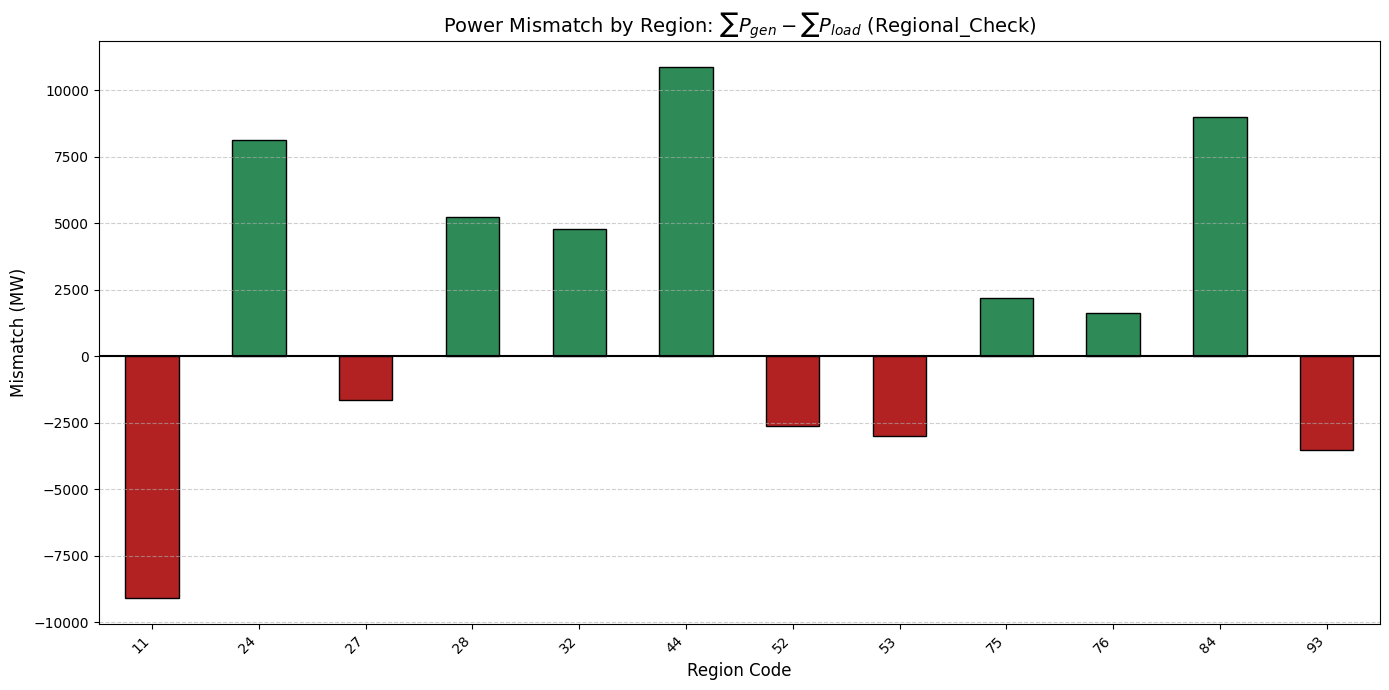

Mismatch report saved: Regional_Check_mismatch_report.pdf


In [116]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_regional_mismatch(df_gen, df_load, dataset_name="Grid_Balance"):
    """
    Calculates Mismatch = Sum(target_p) - Sum(p0) per region
    across two separate DataFrames.
    """
    # 1. Clean and Prepare Generation Data
    df_gen['target_p'] = pd.to_numeric(df_gen['target_p'], errors='coerce').fillna(0)
    gen_sum = df_gen.groupby('region_code')['target_p'].sum().rename('total_gen')

    # 2. Clean and Prepare Load Data
    df_load['p0'] = pd.to_numeric(df_load['p0'], errors='coerce').fillna(0)
    load_sum = df_load.groupby('region_code')['p0'].sum().rename('total_load')

    # 3. Merge the two summaries on region_code
    # How='outer' ensures we don't lose regions that only exist in one table
    comparison = pd.merge(gen_sum, load_sum, on='region_code', how='outer').fillna(0)

    # 4. Calculate Mismatch (Residual)
    comparison['mismatch'] = comparison['total_gen'] - comparison['total_load']
    
    # Sort for better visualization
    # comparison = comparison.sort_values(by='mismatch', ascending=False)

    # 5. Plotting
    plt.figure(figsize=(14, 7))
    
    # Logic: Green for surplus (Gen > Load), Red for deficit (Load > Gen)
    colors = ['seagreen' if x >= 0 else 'firebrick' for x in comparison['mismatch']]
    
    comparison['mismatch'].plot(kind='bar', color=colors, edgecolor='black')
    
    plt.axhline(0, color='black', linewidth=1.5) # The "Balance" line
    plt.title(f'Power Mismatch by Region: $\sum P_{{gen}} - \sum P_{{load}}$ ({dataset_name})', fontsize=14)
    plt.xlabel('Region Code', fontsize=12)
    plt.ylabel('Mismatch (MW)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    
    # 6. Save and Display
    filename = f"{dataset_name}_mismatch_report.pdf"
    plt.savefig(filename)
    plt.show()

    print(f"Mismatch report saved: {filename}")
    
    # Return the dataframe in case you want to inspect the numbers
    return comparison

# --- Example Usage ---


generators_df = df_inj_gen_mw
loads_df = df_inj_load
df_mismatch = plot_regional_mismatch(generators_df, loads_df, "Regional_Check")

## Leftovers

In [117]:
list_files = ['data/recollement-auto-20210101-0000-enrichi.xiidm.bz2', 'data/recollement-auto-20210101-0005-enrichi.xiidm.bz2', 'data/recollement-auto-20210101-0010-enrichi.xiidm.bz2', 'data/recollement-auto-20210101-0005-enrichi.xiidm.bz2',]



vl1data = {}
for i, file in enumerate(list_files):
    grid = pp.network.load(file)
    vl1_values = grid.get_lines(attributes=['voltage_level1_id'])['voltage_level1_id'] 
    timestep = Path(file).stem # Here we use the snapshot name to be the name of the column. You could choose some other name for the columns of the time series.
    vl1data[f'Snap{i}: {timestep}'] = vl1_values

vl1_timeseries = pd.DataFrame(vl1data)

Line parameter distributions

In [118]:
df = grid.get_operational_limits()
df

element_type  \
element_id    side type    acceptable_duration group_name                             
.CTLHL31.CTLO ONE  CURRENT -1                  HIVER1                          LINE   
                            2147483647         HIVER1                          LINE   
              TWO  CURRENT -1                  HIVER1                          LINE   
.CTLHL32.CTLO ONE  CURRENT -1                  HIVER1                          LINE   
                            2147483647         HIVER1                          LINE   
...                                                                             ...   
WEPPEY762     ONE  CURRENT  60                 HIVER1      TWO_WINDINGS_TRANSFORMER   
YAINVY642     ONE  CURRENT -1                  HIVER1      TWO_WINDINGS_TRANSFORMER   
                            1200               HIVER1      TWO_WINDINGS_TRANSFORMER   
                            300                HIVER1      TWO_WINDINGS_TRANSFORMER   
                            60                 HIVER1      TWO_WINDINGS_TRANSFORMER   

                                                                      name  \
element_id    side type    acceptable_duration group_name                    
.CTLHL31.CTLO ONE  CURRENT -1                  HIVER1      permanent_limit   
                            2147483647         HIVER1                  N/A   
              TWO  CURRENT -1                  HIVER1      permanent_limit   
.CTLHL32.CTLO ONE  CURRENT -1                  HIVER1      permanent_limit   
                            2147483647         HIVER1                  N/A   
...                                                                    ...   
WEPPEY762     ONE  CURRENT  60                 HIVER1                  IT1   
YAINVY642     ONE  CURRENT -1                  HIVER1      permanent_limit   
                            1200               HIVER1                 IT20   
                            300                HIVER1                  IT5   
                            60                 HIVER1                  IT1   

                                                                   value  
element_id    side type    acceptable_duration group_name                 
.CTLHL31.CTLO ONE  CURRENT -1                  HIVER1       2.100000e+02  
                            2147483647         HIVER1      1.797693e+308  
              TWO  CURRENT -1                  HIVER1       2.100000e+02  
.CTLHL32.CTLO ONE  CURRENT -1                  HIVER1       2.100000e+02  
                            2147483647         HIVER1      1.797693e+308  
...                                                                  ...  
WEPPEY762     ONE  CURRENT  60                 HIVER1      1.797693e+308  
YAINVY642     ONE  CURRENT -1                  HIVER1       7.750001e+02  
                            1200               HIVER1       9.300001e+02  
                            300                HIVER1       1.240000e+03  
                            60                 HIVER1      1.797693e+308  

[37165 rows x 3 columns]

In [119]:
counts = df.groupby(['element_type', 'type']).size()
counts

element_type              type   
LINE                      CURRENT    31068
TWO_WINDINGS_TRANSFORMER  CURRENT     6097
dtype: int64